# **Analisis EDA**

---
Corresponde a la actividad 3 para tener conocimiento si los datos estan desbalanciados y si es necesario aplicar tecnicas para aumento de datos.


1. Importaciones

In [ ]:
#!pip install roboflow
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
!pip install kagglehub
import kagglehub
import os
import json
import pandas as pd
import seaborn as sns


2. Descargamos el dataset de Roboflow

In [ ]:

# Configurar las credenciales de Kaggle directamente en Colab
kaggle_credentials = {
    "username":"lettycristina",
    "key":"45bb09f6094bf4956dee2a0b9e5de119"
}

# Crear el directorio .kaggle
!mkdir -p ~/.kaggle

# Guardar las credenciales
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

# Establecer permisos
!chmod 600 /root/.kaggle/kaggle.json

# Descargar el dataset desde Kaggle
print("Descargando dataset...")
path = kagglehub.dataset_download("lettycristina/clasificaciondemangoskent")
print("Path to dataset files:", path)

# Configurar la ruta del dataset
dataset_path = path
splits = ['train', 'valid', 'test']

# Verificar que existen los directorios
print("\n📁 Verificando estructura del dataset:")
for split in splits:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        num_files = len(os.listdir(split_path))
        print(f"✓ '{split}' encontrado con {num_files} archivos/carpetas")
    else:
        print(f"✗ '{split}' NO encontrado")

print(f"\n📍 Dataset ubicado en: {dataset_path}")


Descargando dataset...


100%|██████████| 8.79M/8.79M [00:01<00:00, 4.84MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1

📁 Verificando estructura del dataset:
✓ 'train' encontrado con 2 archivos/carpetas
✓ 'valid' encontrado con 2 archivos/carpetas
✓ 'test' encontrado con 2 archivos/carpetas

📍 Dataset ubicado en: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1


3. Analisis preliminar

In [ ]:
class_counts = {}
dimensions = []
rgb_values = []

# Recorremos todas las carpetas (train, valid, test)
for split in splits:
    split_path = os.path.join(dataset_path, split)
    if not os.path.exists(split_path): continue

    classes = os.listdir(split_path)
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            images = glob.glob(os.path.join(cls_path, "*"))

            # Conteo de clases
            if cls not in class_counts: class_counts[cls] = 0
            class_counts[cls] += len(images)

            # Muestreo para dimensiones y RGB (tomamos 20 imágenes por clase para no saturar la RAM)
            for img_path in images[:20]:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convertir a RGB
                    dimensions.append(img.shape[:2]) # Guardar alto y ancho

                    # Calcular histograma simple promedio para esta imagen
                    rgb_values.append(img.mean(axis=(0,1)))


4. Graficamos

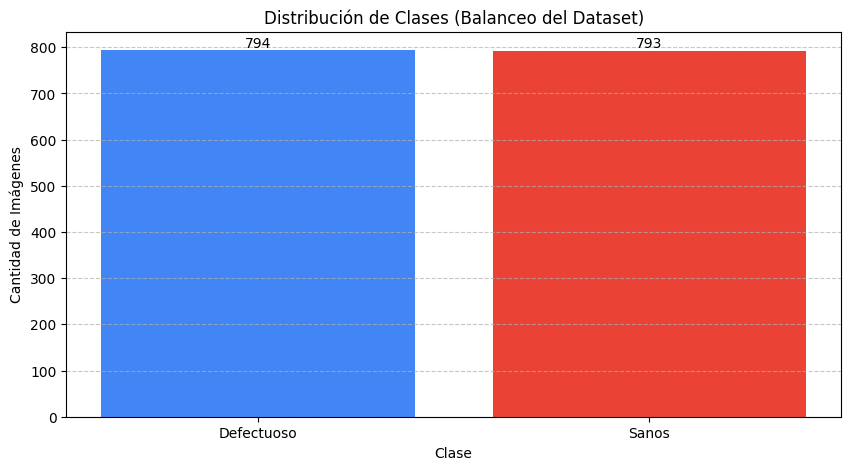

✅ El dataset parece razonablemente balanceado.


In [ ]:
# A) Gráfico de Barras (Distribución de Clases)
plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=['#4285F4', '#EA4335', '#FBBC05'])
plt.title('Distribución de Clases (Balanceo del Dataset)')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Imágenes')
plt.bar_label(bars)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Interpretación automática
cantidades = list(class_counts.values())
if max(cantidades) / min(cantidades) > 1.5:
    print("⚠️ ALERTA: El dataset está DESBALANCEADO. Una clase tiene muchas más imágenes que otra.")
else:
    print("✅ El dataset parece razonablemente balanceado.")


5. Verificamos la estandarización

In [ ]:

# B) Verificación de Dimensiones (Estandarización)
unique_dims = set(dimensions)
print(f"\nDimensiones encontradas en la muestra: {unique_dims}")
if len(unique_dims) == 1:
    print(f"✅ Estandarización Correcta: Todas las imágenes son {list(unique_dims)[0]}")
else:
    print("⚠️ Anomalía: Se encontraron diferentes tamaños de imagen. Roboflow debería haberlas redimensionado.")


Dimensiones encontradas en la muestra: {(224, 224)}
✅ Estandarización Correcta: Todas las imágenes son (224, 224)


6. Histogramas RGB

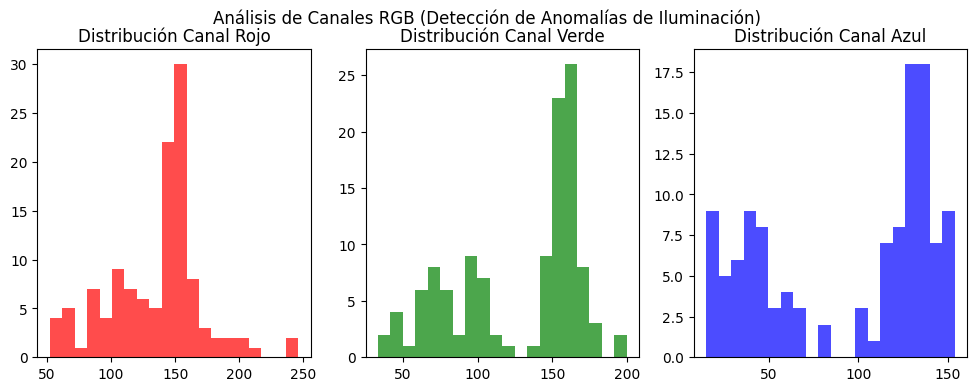

In [ ]:
# C) Histogramas RGB (Anomalías de Color)
# Separamos los valores R, G, B promedios
r_vals = [v[0] for v in rgb_values]
g_vals = [v[1] for v in rgb_values]
b_vals = [v[2] for v in rgb_values]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.hist(r_vals, bins=20, color='red', alpha=0.7); plt.title('Distribución Canal Rojo')
plt.subplot(1, 3, 2); plt.hist(g_vals, bins=20, color='green', alpha=0.7); plt.title('Distribución Canal Verde')
plt.subplot(1, 3, 3); plt.hist(b_vals, bins=20, color='blue', alpha=0.7); plt.title('Distribución Canal Azul')
plt.suptitle('Análisis de Canales RGB (Detección de Anomalías de Iluminación)')
plt.show()


PROCESAMIENTO DE LAS IMAGENES DE ENTRENAMIENTO

In [ ]:
# Obtener las clases del dataset
train_path = os.path.join(dataset_path, 'train')
if os.path.exists(train_path):
    classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]
else:
    print("⚠️ No se encontró la carpeta 'train'")
    classes = []

data = []

print("\n--- PROCESANDO IMÁGENES PARA ANÁLISIS AVANZADO ---")

for label in classes:
    folder_path = os.path.join(train_path, label)
    if not os.path.isdir(folder_path):
        continue

    # Tomamos hasta 100 imágenes por clase
    image_files = glob.glob(os.path.join(folder_path, "*"))[:100]

    for img_path in image_files:
        try:
            img = cv2.imread(img_path)
            if img is None:
                continue

            # 1. Calcular Brillo Promedio
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            brightness = hsv[:,:,2].mean()

            # 2. Calcular Desenfoque (Varianza Laplaciana)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

            # 3. Color Promedio (RGB)
            mean_color = img.mean(axis=(0,1))

            data.append({
                'Clase': label,
                'Brillo': brightness,
                'Nitidez': blur_score,
                'Rojo_Promedio': mean_color[2],
                'Verde_Promedio': mean_color[1],
                'Azul_Promedio': mean_color[0],
                'Ruta': img_path
            })
        except Exception as e:
            print(f"Error procesando {img_path}: {e}")

df = pd.DataFrame(data)

if len(df) > 0:
    print(f"✅ Se procesaron {len(df)} imágenes correctamente")




--- PROCESANDO IMÁGENES PARA ANÁLISIS AVANZADO ---
✅ Se procesaron 200 imágenes correctamente


Visualizaciones

/tmp/ipython-input-4210979290.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clase', y='Brillo', data=df, palette="Set2")


Text(0.5, 1.0, 'Comparación de Brillo (¿Hay sesgo de luz?)')

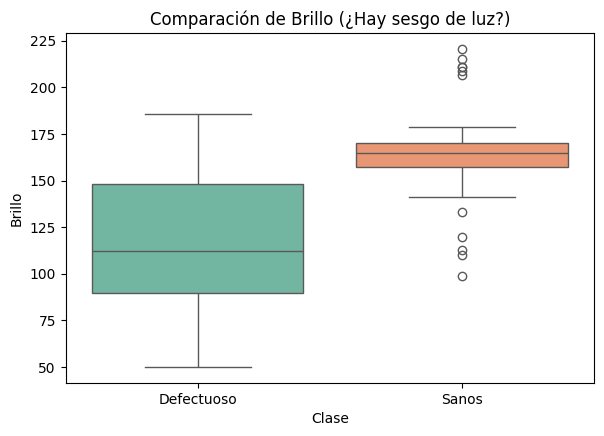

In [ ]:

# --- VISUALIZACIONES ---

plt.figure(figsize=(15, 10))

# GRÁFICO 1: Comparación de Brillo (Boxplot)
plt.subplot(2, 2, 1)
sns.boxplot(x='Clase', y='Brillo', data=df, palette="Set2")
plt.title('Comparación de Brillo (¿Hay sesgo de luz?)')

/tmp/ipython-input-915939285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Clase', y='Nitidez', data=df, palette="Set2")


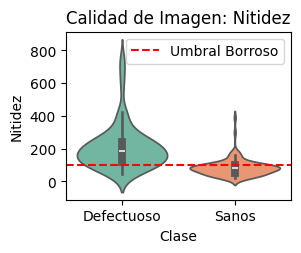

In [ ]:

# GRÁFICO 2: Comparación de Nitidez (Violin Plot)
plt.subplot(2, 2, 2)
sns.violinplot(x='Clase', y='Nitidez', data=df, palette="Set2")
plt.axhline(100, color='red', linestyle='--', label='Umbral Borroso') # Referencia común
plt.title('Calidad de Imagen: Nitidez')
plt.legend()


Text(0.5, 1.0, 'Separación por Color (Rojo vs Verde)')

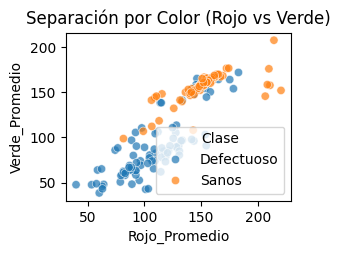

In [ ]:

# GRÁFICO 3: Scatter Plot (Verde vs Rojo)
# Los mangos maduros/sanos suelen tener patrones de verde/rojo distintos a los defectuosos (manchas negras/marrones)
plt.subplot(2, 2, 3)
sns.scatterplot(x='Rojo_Promedio', y='Verde_Promedio', hue='Clase', data=df, alpha=0.7)
plt.title('Separación por Color (Rojo vs Verde)')


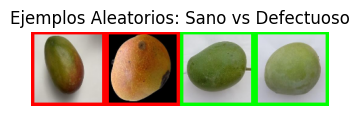

In [ ]:

# GRÁFICO 4: Muestra Visual (Grid)
plt.subplot(2, 2, 4)
plt.axis('off')
plt.title("Ejemplos Aleatorios: Sano vs Defectuoso")

# Mostrar 2 imágenes de cada clase
sample_images = []
for label in classes:
    sample_row = df[df['Clase'] == label].sample(2)
    for _, row in sample_row.iterrows():
        img = cv2.imread(row['Ruta'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        # Poner borde de color según clase
        color_border = [0, 255, 0] if "sano" in label.lower() or "fresh" in label.lower() else [255, 0, 0]
        img = cv2.copyMakeBorder(img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=color_border)
        sample_images.append(img)

if sample_images:
    # Concatenar horizontalmente
    combined_img = np.hstack(sample_images)
    plt.imshow(combined_img)

plt.tight_layout()
plt.show()


In [ ]:

# --- INTERPRETACIÓN AUTOMÁTICA ---
print("\n--- CONCLUSIONES PRELIMINARES ---")
diff_brillo = abs(df[df['Clase']==classes[0]]['Brillo'].mean() - df[df['Clase']==classes[1]]['Brillo'].mean())
if diff_brillo > 40:
    print(f"⚠️ CUIDADO: Hay una gran diferencia de brillo ({diff_brillo:.1f}) entre clases.")
    print("   Solución: Aplica 'RandomBrightness' en el Data Augmentation de Roboflow.")
else:
    print("✅ El brillo parece consistente entre ambas clases.")

img_borrosas = df[df['Nitidez'] < 100].shape[0]
if img_borrosas > 0:
    print(f"⚠️ Se detectaron {img_borrosas} imágenes potencialmente borrosas (Nitidez < 100).")
    print("   Revisa visualmente si necesitas eliminarlas.")


--- CONCLUSIONES PRELIMINARES ---
⚠️ CUIDADO: Hay una gran diferencia de brillo (47.0) entre clases.
   Solución: Aplica 'RandomBrightness' en el Data Augmentation de Roboflow.
⚠️ Se detectaron 89 imágenes potencialmente borrosas (Nitidez < 100).
   Revisa visualmente si necesitas eliminarlas.
